### **K-means Clustering**

**K-means Clustering** is a popular partitioning method used in cluster analysis. The main goal is to partition the dataset into K clusters, where each observation belongs to the cluster with the nearest mean. The steps include:

1. Initialize K centroids randomly.
2. Assign each data point to the nearest centroid.
3. Recalculate the centroids as the mean of all data points assigned to each centroid.
4. Repeat steps 2-3 until the centroids do not change significantly.




### **Hierarchical Clustering**

**Hierarchical clustering** is a method of cluster analysis which seeks to build a hierarchy of clusters. It can be broadly divided into two types:

1. **Agglomerative Clustering (Bottom-Up)**:
    - Starts with each observation as its own cluster.
    - Iteratively merges the closest pairs of clusters until only one cluster remains or a stopping criterion is met.
    - The most common linkage criteria include single, complete, average, and ward linkage.
    
2. **Divisive Clustering (Top-Down)**:
    - Starts with one cluster containing all observations.
    - Iteratively splits the clusters until each observation is in its own cluster or a stopping criterion is met.
    - This method is less common due to its computational complexity.

### **Agglomerative Clustering**

**Agglomerative clustering** is a type of hierarchical clustering that builds nested clusters in a bottom-up manner. It is the most commonly used type of hierarchical clustering and follows these steps:

1. **Calculate the Distance**: Compute the distance between each pair of observations.
2. **Merge Clusters**: Find the two closest clusters and merge them.
3. **Update Distances**: Update the distance matrix to reflect the merged cluster.
4. **Repeat**: Repeat the merging process until only one cluster remains or the desired number of clusters is achieved.

### Key Points

- **Hierarchical Clustering**: An umbrella term for clustering methods that create a hierarchy of clusters.
- **Agglomerative Clustering**: A specific type of hierarchical clustering that starts with individual observations and merges them iteratively.



## **Problem Statement**

The company aims to evaluate the selling performance of its products by analyzing customer buying behavior. Due to the large size of the dataset, traditional manual analysis methods are impractical. The objective is to segment customers into distinct groups based on their purchasing patterns using clustering techniques. This segmentation will help the company understand different customer profiles, enabling more targeted marketing strategies and improving product offerings.




In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#file_path = '/content/drive/My Drive/Retail/Online Retail.xlsx'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [4]:
#load the data
customers = pd.read_excel('/content/Online Retail.xlsx')

In [5]:
#view the first five rows of the data
customers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
#check columns information
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
# drop irrelevant columns
customers = customers.drop(columns=['CustomerID','InvoiceDate','InvoiceNo','StockCode','Description'],axis=1)

In [7]:
#drop missing values
customers = customers.dropna()

In [8]:
#check columns information
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Quantity   541909 non-null  int64  
 1   UnitPrice  541909 non-null  float64
 2   Country    541909 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 12.4+ MB


In [26]:
# reduce dataset to 4000
customers = customers.sample(n=4000,random_state=42)

In [10]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 209268 to 522740
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Quantity   4000 non-null   int64  
 1   UnitPrice  4000 non-null   float64
 2   Country    4000 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 125.0+ KB


In [11]:
#scaling the numerical features
X = customers[['Quantity','UnitPrice']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
#encoding the categorical features
label_encoder = LabelEncoder()
countries_encoded = label_encoder.fit_transform(customers['Country'])

In [13]:
#check the shape of the encoded categorical feature
countries_encoded.shape

(4000,)

In [14]:
#check the shape of the sclaed numerical features
X_scaled.shape

(4000, 2)

In [15]:
#reshaping the encoded categorical feature to 2D
countries_encoded = countries_encoded.reshape(-1,1)

In [16]:
#view the shape of the encoded categorical feature
countries_encoded.shape

(4000, 1)

In [19]:
#Concatenating the scaled numerical features and the encoded categorical feature
X_scaled_with_countries = np.concatenate((X_scaled,countries_encoded),axis=1)

In [20]:
#Silhouette Score Calculation
silhouette_scores = []
cluster_range = range(2,16)
for n in cluster_range:
  kmeans = KMeans(n_clusters=n,random_state=42,n_init='auto')
  kmeans_labels = kmeans.fit_predict(X_scaled_with_countries)
  silhouette_scores.append(silhouette_score(X_scaled_with_countries,kmeans_labels))

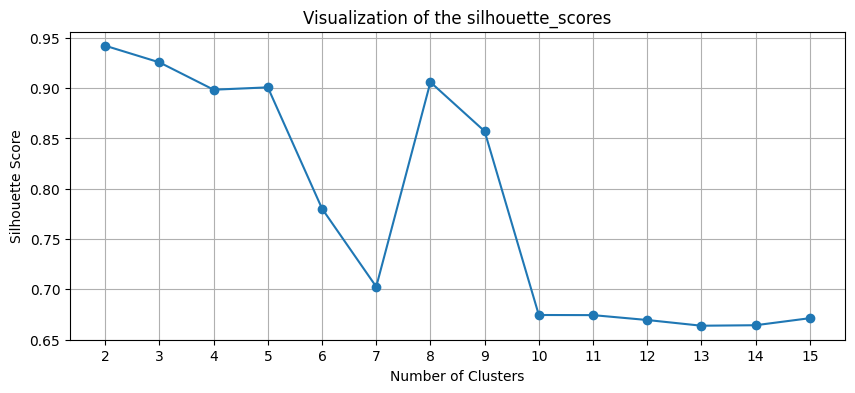

In [21]:
plt.figure(figsize=(10,4))
plt.plot(cluster_range,silhouette_scores,marker='o')
plt.title('Visualization of the silhouette_scores')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(np.arange(2,16,step=1))
plt.grid(True)
plt.show()

In [22]:
#find the optimal number of clusters
optimal_clusters = silhouette_scores.index(max(silhouette_scores)) + 2
print("optimal number of clusters",optimal_clusters)

optimal number of clusters 2


In [23]:
kmeans = KMeans(n_clusters = optimal_clusters,random_state=42,n_init='auto')
kmeans_labels_ = kmeans.fit_predict(X_scaled_with_countries)
score = silhouette_score(X_scaled_with_countries,kmeans_labels_)
print('Silhouette_score : ',score)

Silhouette_score :  0.942278308676521
